## ImmunoStruct vs ImmunoMTL — Novel Split Benchmark

Head-to-head comparison on pHLA pairs **never seen during ImmunoMTL training**.

- **IEDB novel** (N=2,702; 971 pos): IEDB pathogen/viral epitopes not in ImmunoMTL training

ImmunoMTL is evaluated on this held-out IEDB set against ImmunoStruct domain-specific and combined models.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

# ── Load predictions ───────────────────────────────────────────────────────────
df = pd.read_csv("data/test_predictions.csv")   # s22 ImmunoMTL_pred

# IS domain-specific predictions
is_iedb_only = pd.read_csv("models/PropIEDB_ImmunoIEDB_NovelSplit/predictions_novel.csv")

# Build IEDB novel subset
iedb_sub = df[df["source"] == "IEDB"].copy().reset_index(drop=True)
iedb_sub["IS_specific_pred"] = is_iedb_only["IS_pred"].values

print(f"IEDB novel:  {len(iedb_sub)} rows  (pos={iedb_sub['label'].sum()})")


IEDB novel:  2702 rows  (pos=971)


In [5]:
F1_THRESHOLD = 0.5

def ppv_at_10(yt, yp):
    k = max(1, int(len(yp) * 0.10))
    idx = np.argsort(yp)[::-1][:k]
    return float(yt[idx].sum() / k)

def bootstrap_metrics(y_true, y_pred, n=1000, seed=42):
    rng = np.random.default_rng(seed)
    auroc_b, ap_b, ppv_b, f1_b = [], [], [], []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt, yp = y_true[idx], y_pred[idx]
        if yt.sum() == 0 or yt.sum() == len(yt):
            continue
        auroc_b.append(roc_auc_score(yt, yp))
        ap_b.append(average_precision_score(yt, yp))
        ppv_b.append(ppv_at_10(yt, yp))
        f1_b.append(f1_score(yt, (yp >= F1_THRESHOLD).astype(int), zero_division=0))
    return (np.percentile(auroc_b, [2.5, 97.5]),
            np.percentile(ap_b,   [2.5, 97.5]),
            np.percentile(ppv_b,  [2.5, 97.5]),
            np.percentile(f1_b,   [2.5, 97.5]))

def compute_metrics(y_true, y_pred):
    auroc = roc_auc_score(y_true, y_pred)
    ap    = average_precision_score(y_true, y_pred)
    ppv   = ppv_at_10(y_true, y_pred)
    f1    = f1_score(y_true, (y_pred >= F1_THRESHOLD).astype(int))
    ci_a, ci_ap, ci_p, ci_f = bootstrap_metrics(y_true, y_pred)
    return dict(AUROC=round(auroc,3), AUROC_lo=round(ci_a[0],3),  AUROC_hi=round(ci_a[1],3),
                AP=round(ap,3),       AP_lo=round(ci_ap[0],3),    AP_hi=round(ci_ap[1],3),
                PPV10=round(ppv,3),   PPV10_lo=round(ci_p[0],3),  PPV10_hi=round(ci_p[1],3),
                F1=round(f1,3),       F1_lo=round(ci_f[0],3),     F1_hi=round(ci_f[1],3))

MODELS = {
    "ImmunoMTL":    "ImmunoMTL_pred",
    "IS (specific)":"IS_specific_pred",
    "IS Combined":  "IS_combined_pred",
}

rows = []
for ts_name, sub in [("IEDB novel", iedb_sub)]:
    for model, col in MODELS.items():
        vals = sub[col].values.astype(float)
        if np.any(np.isnan(vals)):
            continue
        m = compute_metrics(sub["label"].values.astype(float), vals)
        rows.append({"Test Set": ts_name, "Model": model,
                     "N": len(sub), "Pos": int(sub["label"].sum()), **m})

results = pd.DataFrame(rows)
print(f"F1 threshold: {F1_THRESHOLD}")
print(results[["Test Set","Model","N","Pos",
               "AUROC","AUROC_lo","AUROC_hi",
               "AP","AP_lo","AP_hi",
               "PPV10","PPV10_lo","PPV10_hi",
               "F1","F1_lo","F1_hi"]].to_string(index=False))


F1 threshold: 0.5
  Test Set         Model    N  Pos  AUROC  AUROC_lo  AUROC_hi    AP  AP_lo  AP_hi  PPV10  PPV10_lo  PPV10_hi    F1  F1_lo  F1_hi
IEDB novel     ImmunoMTL 2702  971  0.624     0.604     0.647 0.464  0.434  0.501  0.544     0.493     0.607 0.546  0.526  0.568
IEDB novel IS (specific) 2702  971  0.624     0.601     0.648 0.512  0.479  0.545  0.600     0.541     0.663 0.528  0.504  0.548
IEDB novel   IS Combined 2702  971  0.597     0.574     0.620 0.436  0.406  0.467  0.474     0.411     0.533 0.514  0.490  0.536


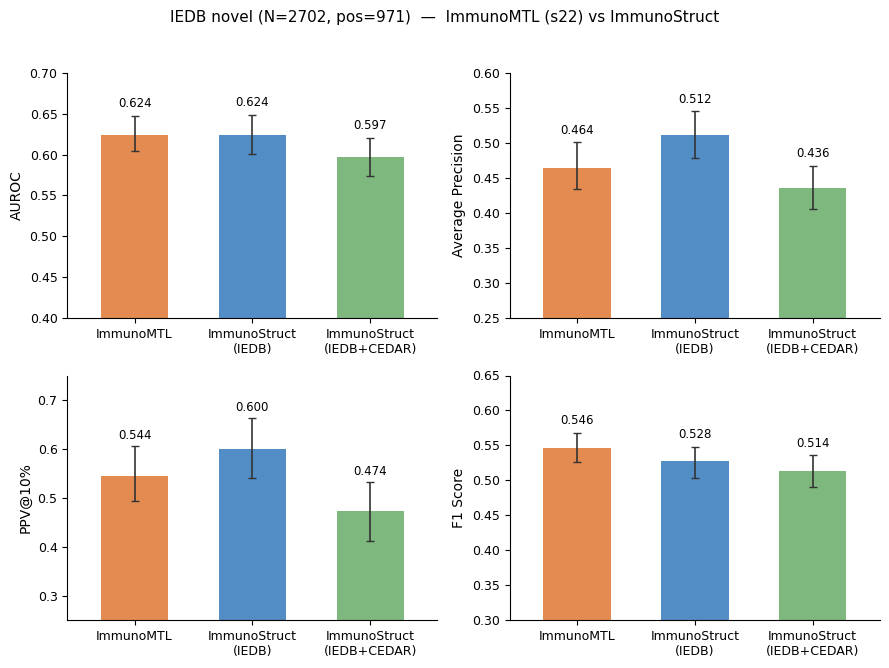

Saved ../sup_figures/is_vs_immunomtl_iedb_2x2.{pdf,png}


In [6]:
import os
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42
os.makedirs("figures", exist_ok=True)

MODEL_LIST = ["ImmunoMTL", "IS (specific)", "IS Combined"]
XLABELS    = ["ImmunoMTL", "ImmunoStruct\n(IEDB)", "ImmunoStruct\n(IEDB+CEDAR)"]
COLORS     = {"ImmunoMTL":    "#E07B39",
              "IS (specific)":"#3A7DBF",
              "IS Combined":  "#6DAF6D"}

METRICS = [
    ("AUROC", "AUROC_lo", "AUROC_hi", 0.40, 0.70, "AUROC"),
    ("AP",    "AP_lo",    "AP_hi",    0.25, 0.60, "Average Precision"),
    ("PPV10", "PPV10_lo", "PPV10_hi", 0.25, 0.75, "PPV@10%"),
    ("F1",    "F1_lo",    "F1_hi",    0.30, 0.65, "F1 Score"),
]

sub = results[results["Test Set"] == "IEDB novel"].set_index("Model")
n_tot = sub.iloc[0]["N"]
n_pos = sub.iloc[0]["Pos"]

fig, axes = plt.subplots(2, 2, figsize=(9, 6.5))
fig.suptitle(f"IEDB novel (N={n_tot}, pos={n_pos})  —  ImmunoMTL (s22) vs ImmunoStruct",
             fontsize=11, y=1.02)

bar_w = 0.08
xs    = np.arange(len(MODEL_LIST)) * (bar_w + 0.06)

for idx, (metric, lo_col, hi_col, ymin, ymax, ylabel) in enumerate(METRICS):
    ax = axes[idx // 2][idx % 2]

    for i, model in enumerate(MODEL_LIST):
        if model not in sub.index:
            continue
        r   = sub.loc[model]
        lo  = r[lo_col]; hi = r[hi_col]; val = r[metric]
        ax.bar(xs[i], val, bar_w, color=COLORS[model], alpha=0.88)
        ax.errorbar(xs[i], val,
                    yerr=[[val - lo], [hi - val]],
                    fmt="none", color="#333", capsize=3, linewidth=1.2)
        ax.text(xs[i], hi + 0.008, f"{val:.3f}",
                ha="center", va="bottom", fontsize=8.5)

    #if metric == "AUROC":
        #ax.axhline(0.5, color="gray", lw=0.8, ls="--")

    ax.set_xticks(xs)
    ax.set_xticklabels(XLABELS, fontsize=9, rotation=0, ha="center")
    ax.set_xlim(xs[0] - bar_w, xs[-1] + bar_w)
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis="y", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../sup_figures/is_vs_immunomtl_iedb_2x2.pdf", bbox_inches="tight")
plt.savefig("../sup_figures/is_vs_immunomtl_iedb_2x2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ../sup_figures/is_vs_immunomtl_iedb_2x2.{pdf,png}")
